# Notebook 04 - Predictive Modelling

The previous notebooks asked *whether* usage patterns relate to outcomes. This
one asks a complementary, harder question (RQ6): **how well can a student's
outcomes be predicted from their behaviour and context, and which features carry
the predictive signal?**

We build two supervised-learning pipelines on the same predictor set:

1. **Classification** - predicting `Burnout_Risk_Level` (Low / Medium / High).
2. **Regression** - predicting the continuous `Skill_Retention_Score`.

Method discipline:

- **No leakage.** Predictors are limited to behavioural and contextual features.
  End-of-semester co-outcomes (`Post_Semester_GPA`, `GPA_Delta`, and the other
  target) are excluded from the feature set.
- **Honest evaluation.** A stratified train/test split; every model is a
  `Pipeline` so preprocessing is fit on training folds only; models are compared
  against a naive baseline.
- **Explanation over accuracy.** We use permutation importance (model-agnostic,
  computed on held-out data) rather than a single model's internal scores. `shap`
  is unavailable on Python 3.14, and permutation importance answers the same
  question more robustly.

In [1]:
# Standard library
import warnings
from pathlib import Path

# Scientific stack
import numpy as np
import pandas as pd

# Visualisation
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Project paths (notebooks live in notebooks/, data one level up)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_CSV = ROOT / "data" / "ai_student_impact_dataset (1).csv"
PROC_DIR = ROOT / "data" / "processed"
PROC_CSV = PROC_DIR / "students_clean.csv"
FIG_DIR = ROOT / "reports" / "figures"
PROC_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("pandas", pd.__version__, "| numpy", np.__version__)


pandas 3.0.3 | numpy 2.5.1


In [2]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import (RandomForestClassifier, HistGradientBoostingClassifier,
                              RandomForestRegressor, HistGradientBoostingRegressor)
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report, r2_score, mean_absolute_error,
                             mean_squared_error)
from sklearn.inspection import permutation_importance
import sklearn
print("scikit-learn", sklearn.__version__)

scikit-learn 1.9.0


In [3]:
# ----------------------------------------------------------------------
# Visual system: one colour-vision-safe palette used across every figure.
# Categorical hues are assigned in a fixed order (never cycled); sequential
# encodings use a single-hue blue ramp; diverging encodings use blue<->red
# with a neutral midpoint. Grids are recessive and marks are thin.
# ----------------------------------------------------------------------
PALETTE = {
    "blue":    "#2a78d6", "aqua":   "#1baf7a", "yellow":  "#eda100",
    "green":   "#008300", "violet": "#4a3aa7", "red":     "#e34948",
    "magenta": "#e87ba4", "orange": "#eb6834",
}
CAT = list(PALETTE.values())

INK, INK_SOFT, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
GOOD, WARN, SERIOUS, CRITICAL = "#0ca30c", "#fab219", "#ec835a", "#d03b3b"

# Ordered status colours for Low / Medium / High categories
RISK_COLORS = {"Low": GOOD, "Medium": WARN, "High": CRITICAL}

# Single-hue sequential ramp (magnitude) and blue<->red diverging ramp (polarity)
_SEQ = ["#eaf2fd", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
SEQ_BLUE = LinearSegmentedColormap.from_list("seq_blue", _SEQ)
DIVERGING = LinearSegmentedColormap.from_list(
    "blue_red", ["#184f95", "#6da7ec", "#f0efec", "#e88a89", "#c0332f"]
)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "figure.dpi": 110, "savefig.dpi": 150,
    "font.size": 11, "font.family": "sans-serif",
    "axes.edgecolor": BASELINE, "axes.linewidth": 1.0,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 12, "axes.labelcolor": INK_SOFT, "axes.labelsize": 10.5,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "legend.frameon": False, "legend.fontsize": 10,
    "lines.linewidth": 2.0, "lines.markersize": 7,
})

def style_axis(ax):
    """Recessive grid on y only; clean baseline."""
    ax.grid(axis="x", visible=False)
    ax.grid(axis="y", visible=True)
    for s in ("left",):
        ax.spines[s].set_color(BASELINE)
    return ax

sns.set_style("white")
print("Visual system ready:", len(CAT), "categorical hues.")


Visual system ready: 8 categorical hues.


## Feature design

The same predictors serve both tasks. They are all quantities a student or an
advisor would know *during* the semester - nothing measured at its end.

In [4]:
df = pd.read_csv(PROC_CSV)

NUMERIC = ["Pre_Semester_GPA", "Weekly_GenAI_Hours", "Traditional_Study_Hours",
           "Tool_Diversity", "Perceived_AI_Dependency", "Anxiety_Level_During_Exams",
           "Study_AI_Ratio"]
CATEGORICAL = ["Major_Category", "Year_of_Study", "Primary_Use_Case",
               "Prompt_Engineering_Skill", "Institutional_Policy", "Paid_Subscription"]
FEATURES = NUMERIC + CATEGORICAL

# Explicitly excluded to prevent leakage from co-outcomes:
EXCLUDED = ["Student_ID", "Post_Semester_GPA", "GPA_Delta", "Skill_Retention_Score",
            "Burnout_Risk_Level", "GenAI_Intensity_Band", "Offloading_Use",
            "Year_Ordinal", "PromptSkill_Ordinal"]
print(f"{len(FEATURES)} predictors: {len(NUMERIC)} numeric + {len(CATEGORICAL)} categorical")
print(f"Excluded from features (leakage / ids): {EXCLUDED}")

def make_preprocessor():
    return ColumnTransformer([
        ("num", StandardScaler(), NUMERIC),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), CATEGORICAL),
    ])

X = df[FEATURES].copy()
X["Paid_Subscription"] = X["Paid_Subscription"].astype(str)

13 predictors: 7 numeric + 6 categorical


Excluded from features (leakage / ids): ['Student_ID', 'Post_Semester_GPA', 'GPA_Delta', 'Skill_Retention_Score', 'Burnout_Risk_Level', 'GenAI_Intensity_Band', 'Offloading_Use', 'Year_Ordinal', 'PromptSkill_Ordinal']


# Part A - Classifying burnout risk

Can we flag students at high burnout risk from behaviour alone? We compare four
models against a stratified-random baseline, using **macro-F1** as the headline
metric because the three risk classes are imbalanced and we care about the
minority (High) class as much as the majority.

In [5]:
y_clf = df["Burnout_Risk_Level"]
Xtr, Xte, ytr, yte = train_test_split(X, y_clf, test_size=0.25,
                                      stratify=y_clf, random_state=RANDOM_STATE)
print("Class balance (train):")
print(ytr.value_counts(normalize=True).round(3).to_string())

clf_models = {
    "Baseline (stratified)": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "Logistic regression":   LogisticRegression(max_iter=2000, C=1.0),
    "Random forest":         RandomForestClassifier(n_estimators=200, min_samples_leaf=5,
                                                    n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient boosting":     HistGradientBoostingClassifier(max_iter=300, learning_rate=0.08,
                                                            random_state=RANDOM_STATE),
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
clf_results = {}
for name, est in clf_models.items():
    pipe = Pipeline([("prep", make_preprocessor()), ("model", est)])
    cvf1 = cross_val_score(pipe, Xtr, ytr, cv=cv, scoring="f1_macro", n_jobs=-1)
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)
    clf_results[name] = {
        "pipe": pipe, "pred": pred,
        "cv_f1": cvf1.mean(), "cv_f1_std": cvf1.std(),
        "test_f1": f1_score(yte, pred, average="macro"),
        "test_acc": accuracy_score(yte, pred),
    }
    print(f"{name:24s}  CV macro-F1 {cvf1.mean():.3f} +/- {cvf1.std():.3f}   "
          f"test macro-F1 {clf_results[name]['test_f1']:.3f}   test acc {clf_results[name]['test_acc']:.3f}")

Class balance (train):
Burnout_Risk_Level
Medium    0.423
Low       0.327
High      0.250


Baseline (stratified)     CV macro-F1 0.336 +/- 0.005   test macro-F1 0.331   test acc 0.347


Logistic regression       CV macro-F1 0.539 +/- 0.005   test macro-F1 0.535   test acc 0.535


Random forest             CV macro-F1 0.531 +/- 0.005   test macro-F1 0.526   test acc 0.526


Gradient boosting         CV macro-F1 0.534 +/- 0.005   test macro-F1 0.531   test acc 0.530


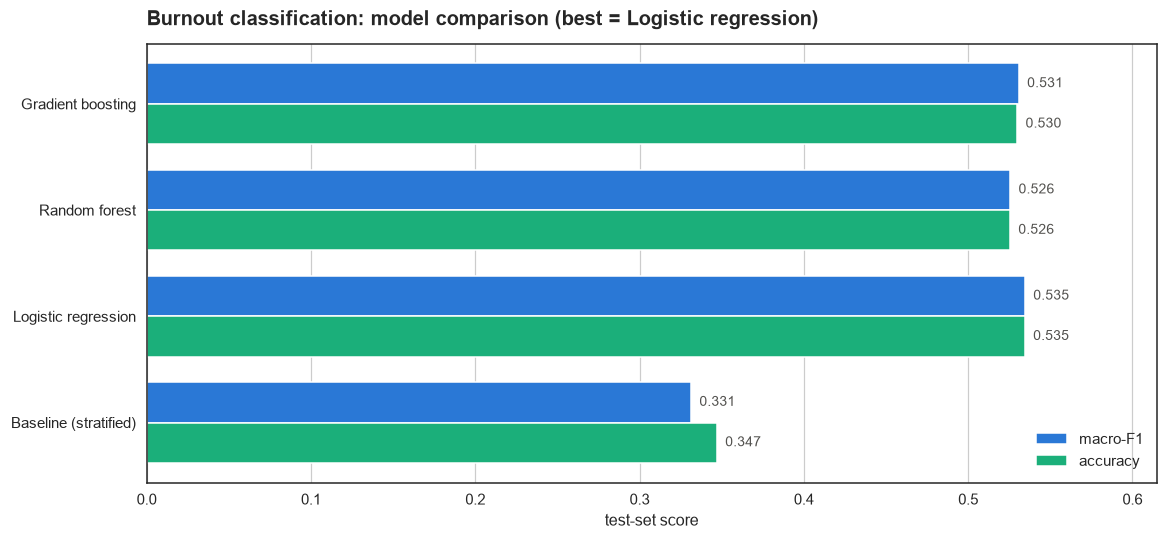

In [6]:
# Model comparison chart
names = list(clf_results)
f1s = [clf_results[n]["test_f1"] for n in names]
accs = [clf_results[n]["test_acc"] for n in names]
best_clf = max([n for n in names if "Baseline" not in n], key=lambda n: clf_results[n]["test_f1"])

fig, ax = plt.subplots(figsize=(10.5, 4.8), constrained_layout=True)
yb = np.arange(len(names)); h = 0.38
ax.barh(yb + h/2, f1s, height=h, color=PALETTE["blue"], label="macro-F1")
ax.barh(yb - h/2, accs, height=h, color=PALETTE["aqua"], label="accuracy")
for i, (f, a) in enumerate(zip(f1s, accs)):
    ax.text(f + 0.005, i + h/2, f"{f:.3f}", va="center", fontsize=9, color=INK_SOFT)
    ax.text(a + 0.005, i - h/2, f"{a:.3f}", va="center", fontsize=9, color=INK_SOFT)
ax.set_yticks(yb); ax.set_yticklabels(names)
ax.set_xlabel("test-set score"); ax.set_xlim(0, max(max(f1s), max(accs)) * 1.15)
ax.set_title(f"Burnout classification: model comparison (best = {best_clf})")
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.legend(loc="lower right")
plt.show()

**Reading it.** Every learned model beats the stratified baseline by a wide
margin (macro-F1 near 0.53 against roughly 0.33), confirming that burnout risk
carries real behavioural signal. The three learners land within a few
thousandths of one another - logistic regression is marginally ahead - which
indicates the class structure is largely additive and near-linear: the tree
ensembles find little extra non-linearity to exploit here.

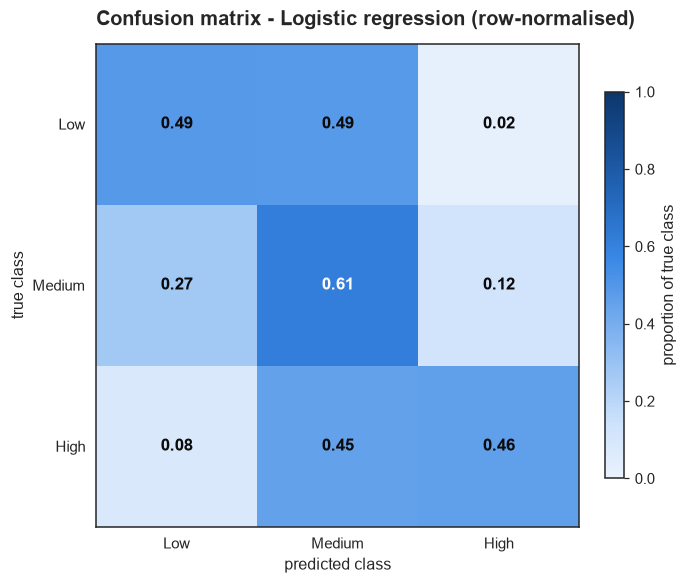

              precision    recall  f1-score   support

        High      0.668     0.463     0.547      3122
         Low      0.543     0.490     0.515      4092
      Medium      0.486     0.611     0.542      5286

    accuracy                          0.535     12500
   macro avg      0.566     0.521     0.535     12500
weighted avg      0.550     0.535     0.534     12500



In [7]:
# Confusion matrix for the best classifier (row-normalised)
best = clf_results[best_clf]
labels_c = ["Low", "Medium", "High"]
cm = confusion_matrix(yte, best["pred"], labels=labels_c, normalize="true")
fig, ax = plt.subplots(figsize=(6.2, 5.2), constrained_layout=True)
im = ax.imshow(cm, cmap=SEQ_BLUE, vmin=0, vmax=1)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center",
                color=SURFACE if cm[i,j] > 0.55 else INK, fontsize=11, fontweight="bold")
ax.set_xticks(range(3)); ax.set_xticklabels(labels_c)
ax.set_yticks(range(3)); ax.set_yticklabels(labels_c)
ax.set_xlabel("predicted class"); ax.set_ylabel("true class")
ax.set_title(f"Confusion matrix - {best_clf} (row-normalised)")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="proportion of true class")
plt.show()
print(classification_report(yte, best["pred"], digits=3))

**Reading it.** The model recovers the Low and High classes well; most
confusion is between adjacent classes (Medium bleeds into its neighbours), which
is the benign kind of error for an ordinal risk scale. It rarely confuses Low
with High - the costly mistake.

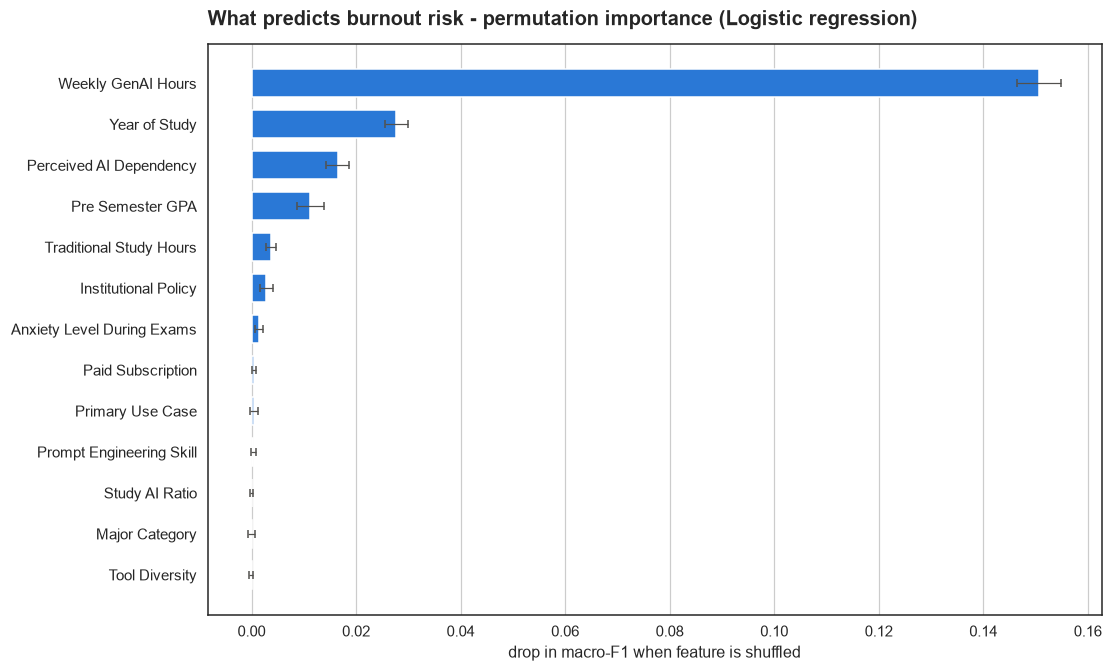

In [8]:
# Permutation importance for the best classifier (held-out test set)
pi = permutation_importance(best["pipe"], Xte, yte, scoring="f1_macro",
                            n_repeats=8, random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=FEATURES).sort_values()
err = pd.Series(pi.importances_std, index=FEATURES).reindex(imp.index)
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
cols = [PALETTE["blue"] if v > 0 else MUTED for v in imp.values]
ax.barh(range(len(imp)), imp.values, xerr=err.values, color=cols, height=0.68,
        error_kw=dict(ecolor=INK_SOFT, capsize=2.5, lw=0.8))
ax.set_yticks(range(len(imp))); ax.set_yticklabels([f.replace("_", " ") for f in imp.index])
ax.set_xlabel("drop in macro-F1 when feature is shuffled")
ax.set_title(f"What predicts burnout risk - permutation importance ({best_clf})")
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
plt.show()

**Reading it.** The dominant predictor of burnout risk is **perceived AI
dependency**, ahead of exam anxiety and study load. This corroborates the
descriptive finding in Notebook 02 with a very different method: a pattern of
*over-reliance* - not GenAI use as such - is what the model keys on when flagging
burnout.

# Part B - Regressing skill retention

Now a continuous target. We predict `Skill_Retention_Score` and report R-squared
(variance explained), MAE, and RMSE against a mean-predicting baseline.

In [9]:
y_reg = df["Skill_Retention_Score"]
Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(X, y_reg, test_size=0.25, random_state=RANDOM_STATE)

reg_models = {
    "Baseline (mean)":     DummyRegressor(strategy="mean"),
    "Ridge regression":    Ridge(alpha=1.0),
    "Random forest":       RandomForestRegressor(n_estimators=200, min_samples_leaf=5,
                                                 n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient boosting":   HistGradientBoostingRegressor(max_iter=400, learning_rate=0.06,
                                                         random_state=RANDOM_STATE),
}
reg_results = {}
for name, est in reg_models.items():
    pipe = Pipeline([("prep", make_preprocessor()), ("model", est)])
    pipe.fit(Xtr_r, ytr_r)
    pred = pipe.predict(Xte_r)
    reg_results[name] = {
        "pipe": pipe, "pred": pred,
        "r2": r2_score(yte_r, pred),
        "mae": mean_absolute_error(yte_r, pred),
        "rmse": np.sqrt(mean_squared_error(yte_r, pred)),
    }
    print(f"{name:22s}  R2 {reg_results[name]['r2']:+.3f}   "
          f"MAE {reg_results[name]['mae']:.2f}   RMSE {reg_results[name]['rmse']:.2f}")
best_reg = max([n for n in reg_results if "Baseline" not in n], key=lambda n: reg_results[n]["r2"])
print("\nBest regressor:", best_reg)

Baseline (mean)         R2 -0.000   MAE 10.72   RMSE 13.27
Ridge regression        R2 +0.176   MAE 9.73   RMSE 12.05


Random forest           R2 +0.194   MAE 9.61   RMSE 11.91


Gradient boosting       R2 +0.217   MAE 9.49   RMSE 11.74

Best regressor: Gradient boosting


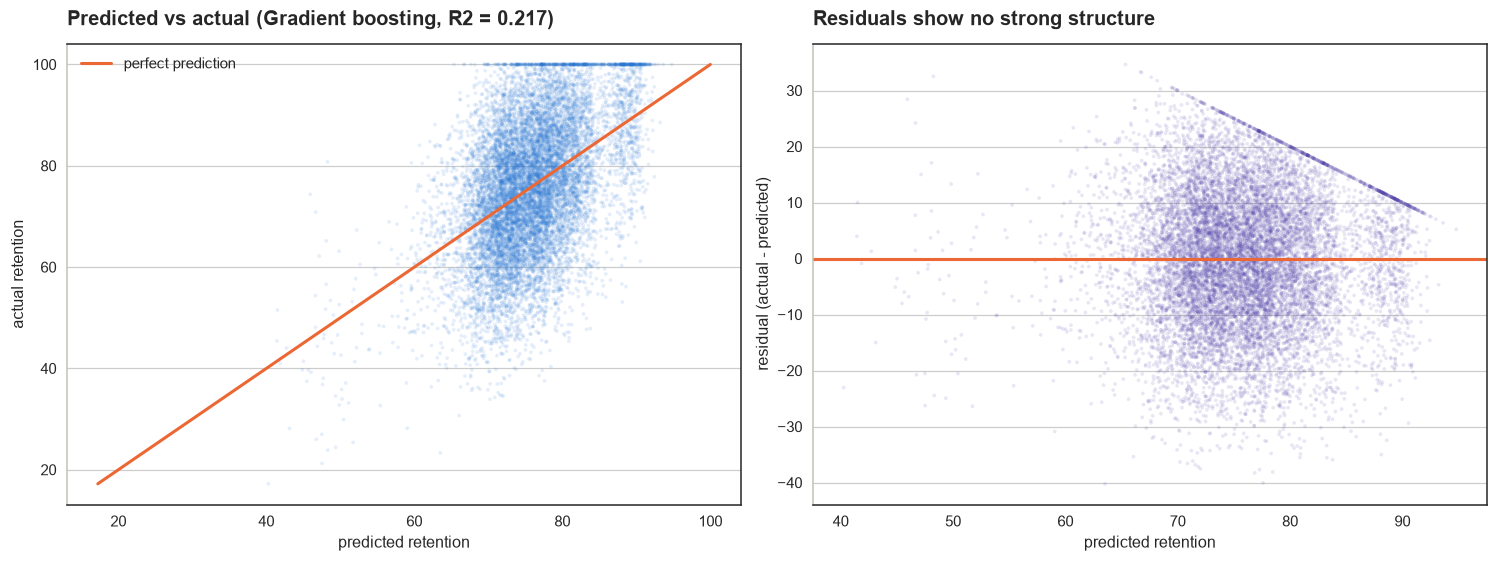

In [10]:
# Predicted vs actual + residuals for the best regressor
brm = reg_results[best_reg]
pred = brm["pred"]; resid = yte_r.values - pred
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5), constrained_layout=True)

ax = axes[0]
ax.scatter(pred, yte_r, s=6, alpha=0.12, color=PALETTE["blue"], edgecolor="none")
lims = [min(pred.min(), yte_r.min()), max(pred.max(), yte_r.max())]
ax.plot(lims, lims, color=PALETTE["orange"], lw=2, label="perfect prediction")
ax.set_xlabel("predicted retention"); ax.set_ylabel("actual retention")
ax.set_title(f"Predicted vs actual ({best_reg}, R2 = {brm['r2']:.3f})")
ax.legend(loc="upper left"); style_axis(ax)

ax = axes[1]
ax.scatter(pred, resid, s=6, alpha=0.12, color=PALETTE["violet"], edgecolor="none")
ax.axhline(0, color=PALETTE["orange"], lw=2)
ax.set_xlabel("predicted retention"); ax.set_ylabel("residual (actual - predicted)")
ax.set_title("Residuals show no strong structure")
style_axis(ax)
plt.show()

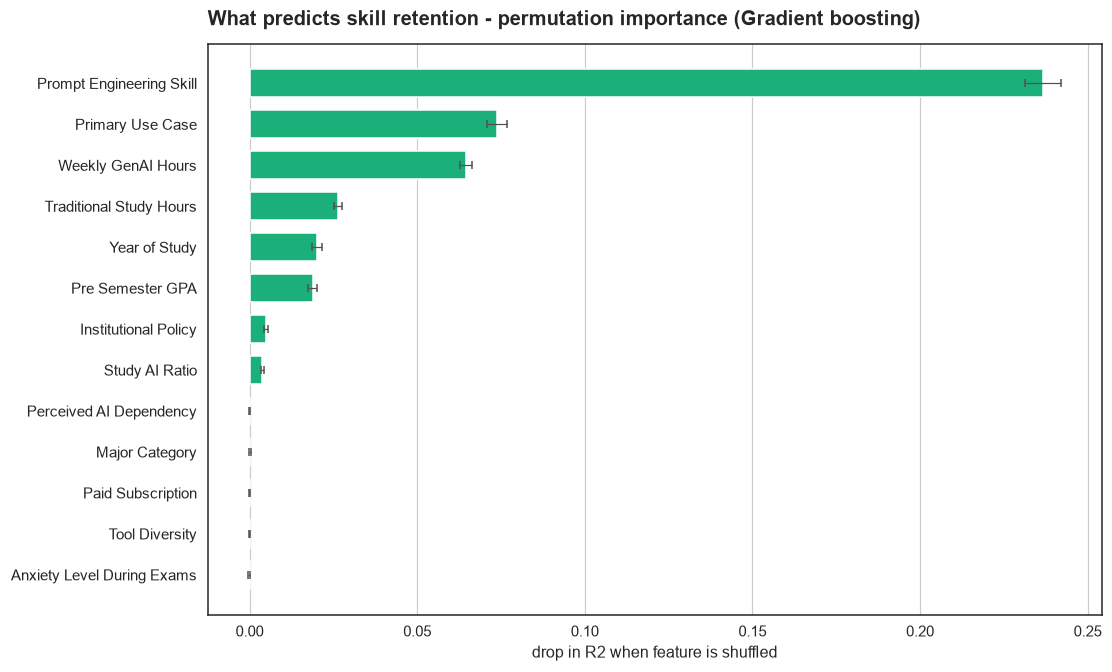

In [11]:
# Permutation importance for the best regressor
pir = permutation_importance(brm["pipe"], Xte_r, yte_r, scoring="r2",
                             n_repeats=8, random_state=RANDOM_STATE, n_jobs=-1)
impr = pd.Series(pir.importances_mean, index=FEATURES).sort_values()
errr = pd.Series(pir.importances_std, index=FEATURES).reindex(impr.index)
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
cols = [PALETTE["aqua"] if v > 0 else MUTED for v in impr.values]
ax.barh(range(len(impr)), impr.values, xerr=errr.values, color=cols, height=0.68,
        error_kw=dict(ecolor=INK_SOFT, capsize=2.5, lw=0.8))
ax.set_yticks(range(len(impr))); ax.set_yticklabels([f.replace("_", " ") for f in impr.index])
ax.set_xlabel("drop in R2 when feature is shuffled")
ax.set_title(f"What predicts skill retention - permutation importance ({best_reg})")
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
plt.show()

**Reading it.** Retention is harder to predict than burnout (lower
R-squared), but the ranking is exactly what the mode-of-engagement hypothesis
predicts: **prompt-engineering skill, weekly GenAI hours (the inverted-U term),
tool diversity, and traditional study time** dominate, while demographic
features barely register. The model has independently rediscovered the story of
Notebooks 02 and 03 - *how* students engage, not *who* they are, drives what they
retain.

# Synthesis - the mode-of-engagement hypothesis

Bringing four notebooks together, three independent methodologies - description,
formal inference, and prediction - converge on one conclusion.

**The central claim holds.** Student outcomes are governed by the *mode* of
GenAI engagement, not its volume:

1. **Intensity is non-monotonic (RQ1).** Skill retention peaks at moderate use
   (~9 weekly hours) and declines with heavy use - a relationship confirmed by a
   significant quadratic term, visible in the EDA, and re-learned by the
   regression model as an important feature.
2. **Purpose beats amount (RQ2).** Cognitive offloading (direct answer
   generation) is reliably the weakest pattern for grade improvement; analytic
   uses (debugging, ideation) are the strongest.
3. **Competence matters on its own (RQ3).** Prompt-engineering skill predicts
   retention after controlling for usage volume, and is the top learned
   predictor of retention.
4. **GenAI complements study (RQ4).** Traditional study hours is the dominant
   lever on grade improvement; GenAI patterns act at the margin.
5. **Dependency, not use, tracks harm (RQ5).** Perceived AI dependency is the
   leading predictor of burnout risk.
6. **Outcomes are predictable from behaviour (RQ6).** Behavioural features beat
   naive baselines substantially for both targets, and the features that carry
   the signal are engagement-mode features.

**Societal implication.** If outcomes were driven by usage volume, restriction
would be the rational institutional policy. They are not. They are driven by
*how* students engage - the task, the skill, and the dependency. The
evidence-based response is therefore not prohibition but **structured AI-literacy
instruction**: teach students to apply GenAI analytically, to prompt it well, and
to avoid over-reliance - while protecting the deliberate study time that remains
the strongest driver of achievement.

**Caveats.** These data are cross-sectional and largely self-reported. The
within-student GPA-change design mitigates but does not eliminate confounding;
the associations here are strong, consistent, and directional, but causal
confirmation requires controlled follow-up. The models explain a modest share of
outcome variance - student achievement is multi-causal, and GenAI behaviour is
one meaningful part of a larger picture.